# Mask2Former — Avraham Improvement Experiment

This notebook is a **targeted refinement experiment** built from the strongest parts of the AVRAHAM and NOA notebooks.

Main goals:

1. Preserve AVRAHAM's strong overall performance.
2. Fix the training representation so that **different instances of the same class stay separate**.
3. Improve learning of **small / rare car parts** without hard-coding weights from the test set.
4. Use a more stable optimization schedule: backbone LR < head LR, warmup + cosine, AMP, gradient clipping, early stopping.
5. Use only the **validation set** for checkpoint selection. The external test evaluator should be run only after training is finished.

> Important methodological note: we already inspected test-set weaknesses. To avoid further test leakage, this notebook does **not** select epochs or hyperparameters using the test set.


In [1]:
# Cell 1 — Install dependencies

%pip install -q "transformers>=4.51,<6" accelerate torchvision pandas matplotlib opencv-python-headless pillow



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2 — Imports and reproducibility

import os
import json
import math
import time
import random
import zipfile
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from PIL import Image, ImageOps, ImageEnhance, ImageFilter

from transformers import (
    AutoImageProcessor,
    Mask2FormerConfig,
    Mask2FormerForUniversalSegmentation,
    get_cosine_schedule_with_warmup,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
# Cell 3 — Paths and experiment configuration
#
# Edit only the paths below before running.

TRAIN_ZIP_PATH = "./train.zip"
VAL_ZIP_PATH   = "./val.zip"

TRAIN_EXTRACT_TO = "./m2f_improved_train"
VAL_EXTRACT_TO   = "./m2f_improved_val"

# Recommended: start from the trained AVRAHAM checkpoint to preserve what it already learned.
# If the directory does not exist, the notebook falls back to the original COCO-pretrained model.
AVRAHAM_MODEL_DIR = "/tf/Avraham_Mask2Former/saved_baseline_mask2former"
BASE_MODEL_NAME = "facebook/mask2former-swin-tiny-coco-instance"

OUTPUT_DIR = Path("./mask2former_avraham_improved_best")
HISTORY_CSV = Path("./mask2former_avraham_improved_history.csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Architecture
NUM_QUERIES = 100

# Higher input resolution helps preserve small parts.
# If VRAM is insufficient, reduce to 448 or 384.
TRAIN_SHORTEST_EDGE = 512

# Effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 0

MAX_EPOCHS = 40

# Stable fine-tuning: backbone learns more slowly than the task-specific layers.
MAIN_LR = 3e-5
BACKBONE_LR = 6e-6
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 3
GRADIENT_CLIP_NORM = 1.0

EARLY_STOPPING_PATIENCE = 7
MIN_MIOU_IMPROVEMENT = 0.001
VALIDATION_THRESHOLD = 0.50

# Data balancing / augmentation
USE_WEIGHTED_SAMPLER = True
USE_HORIZONTAL_FLIP = True
HORIZONTAL_FLIP_P = 0.50
USE_PHOTOMETRIC_AUG = True

# A "small" polygon here means < 2% of image area.
SMALL_OBJECT_AREA_THRESHOLD = 0.02
SMALL_OBJECT_IMAGE_BONUS = 0.50
MAX_IMAGE_SAMPLING_WEIGHT = 3.0

print("Output:", OUTPUT_DIR.resolve())


Output: /tf/Noa_new/Car_parts/mask2former_avraham_improved_best


In [4]:
# Cell 4 — Extract and validate datasets

def extract_zip_if_needed(zip_path, extract_to, split_name):
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)

    if not zip_path.is_file():
        raise FileNotFoundError(f"{split_name} ZIP not found: {zip_path}")

    images_dir = extract_to / "images"
    labels_dir = extract_to / "labels"

    if images_dir.is_dir() and labels_dir.is_dir() and any(images_dir.iterdir()):
        print(f"{split_name}: already extracted")
        return

    extract_to.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {split_name}: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)

extract_zip_if_needed(TRAIN_ZIP_PATH, TRAIN_EXTRACT_TO, "Train")
extract_zip_if_needed(VAL_ZIP_PATH, VAL_EXTRACT_TO, "Validation")

TRAIN_IMAGES_DIR = Path(TRAIN_EXTRACT_TO) / "images"
TRAIN_LABELS_DIR = Path(TRAIN_EXTRACT_TO) / "labels"
VAL_IMAGES_DIR = Path(VAL_EXTRACT_TO) / "images"
VAL_LABELS_DIR = Path(VAL_EXTRACT_TO) / "labels"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def validate_split(images_dir, labels_dir, name):
    images = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])
    labels = sorted(labels_dir.glob("*.txt"))
    if not images:
        raise RuntimeError(f"No images in {images_dir}")
    print(f"{name}: {len(images)} images, {len(labels)} label files")

validate_split(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, "Train")
validate_split(VAL_IMAGES_DIR, VAL_LABELS_DIR, "Validation")


Train: already extracted
Validation: already extracted
Train: 2683 images, 2683 label files
Validation: 575 images, 575 label files


In [5]:
# Cell 5 — The authoritative 23-class mapping

id2label = {
    0: "back_bumper",
    1: "back_door",
    2: "back_glass",
    3: "back_left_door",
    4: "back_left_light",
    5: "back_light",
    6: "back_right_door",
    7: "back_right_light",
    8: "front_bumper",
    9: "front_door",
    10: "front_glass",
    11: "front_left_door",
    12: "front_left_light",
    13: "front_light",
    14: "front_right_door",
    15: "front_right_light",
    16: "hood",
    17: "left_mirror",
    18: "object",
    19: "right_mirror",
    20: "tailgate",
    21: "trunk",
    22: "wheel",
}

label2id = {name: idx for idx, name in id2label.items()}
NUM_CLASSES = len(id2label)

# Horizontal flip must swap left/right semantic labels.
HFLIP_CLASS_SWAP = {
    label2id["back_left_door"]: label2id["back_right_door"],
    label2id["back_right_door"]: label2id["back_left_door"],
    label2id["back_left_light"]: label2id["back_right_light"],
    label2id["back_right_light"]: label2id["back_left_light"],
    label2id["front_left_door"]: label2id["front_right_door"],
    label2id["front_right_door"]: label2id["front_left_door"],
    label2id["front_left_light"]: label2id["front_right_light"],
    label2id["front_right_light"]: label2id["front_left_light"],
    label2id["left_mirror"]: label2id["right_mirror"],
    label2id["right_mirror"]: label2id["left_mirror"],
}

assert NUM_CLASSES == 23
print("Classes:", NUM_CLASSES)


Classes: 23


In [6]:
# Cell 6 — Parse YOLO polygons and inspect class / size distribution

def polygon_area_normalized(points):
    # points are normalized x,y in [0,1]
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def read_yolo_instances(label_path):
    instances = []
    if not Path(label_path).exists():
        return instances

    with open(label_path, "r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            parts = line.strip().split()
            if len(parts) < 7:
                continue

            class_id = int(float(parts[0]))
            if class_id not in id2label:
                raise ValueError(f"{label_path} line {line_number}: invalid class {class_id}")

            coords = np.asarray([float(v) for v in parts[1:]], dtype=np.float32)
            if coords.size % 2 != 0:
                raise ValueError(f"{label_path} line {line_number}: odd coordinate count")

            polygon = coords.reshape(-1, 2)
            if len(polygon) < 3:
                continue

            polygon = np.clip(polygon, 0.0, 1.0)
            instances.append({
                "class_id": class_id,
                "polygon": polygon,
                "area_norm": polygon_area_normalized(polygon),
            })
    return instances

train_image_paths = sorted([p for p in TRAIN_IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS])

class_counts = Counter()
small_counts = Counter()
image_instance_cache = {}

for image_path in train_image_paths:
    instances = read_yolo_instances(TRAIN_LABELS_DIR / f"{image_path.stem}.txt")
    image_instance_cache[image_path.name] = instances

    for inst in instances:
        class_counts[inst["class_id"]] += 1
        if inst["area_norm"] < SMALL_OBJECT_AREA_THRESHOLD:
            small_counts[inst["class_id"]] += 1

stats_rows = []
for class_id in range(NUM_CLASSES):
    count = class_counts[class_id]
    small = small_counts[class_id]
    stats_rows.append({
        "class_id": class_id,
        "class_name": id2label[class_id],
        "instances": count,
        "small_instances": small,
        "small_fraction": small / count if count else 0.0,
    })

train_stats = pd.DataFrame(stats_rows)
display(train_stats.sort_values(["instances", "small_fraction"], ascending=[True, False]))


,class_id,class_name,instances,small_instances,small_fraction
18,18,object,8,8,1.000000
20,20,tailgate,71,3,0.042254
21,21,trunk,121,9,0.074380
6,6,back_right_door,157,22,0.140127
7,7,back_right_light,169,143,0.846154
14,14,front_right_door,174,13,0.074713
3,3,back_left_door,178,35,0.196629
11,11,front_left_door,195,12,0.061538
4,4,back_left_light,204,184,0.901961
15,15,front_right_light,332,304,0.915663


## Why the dataset representation changes here

The original AVRAHAM and NOA notebooks painted the segmentation map with the **class id**.

For semantic segmentation this is fine, but for instance segmentation it can merge two objects of the same class into one target. A typical example is `wheel`: multiple wheels can share class 22.

This notebook instead creates:

- a segmentation map whose pixels contain a **unique instance id**
- an `instance_id_to_semantic_id` dictionary mapping each instance to one of the 23 classes

That is the representation expected by the Mask2Former image processor for instance segmentation.


In [7]:
# Cell 7 — Instance-aware dataset + synchronized augmentation

class CarPartsInstanceDataset(Dataset):
    def __init__(
        self,
        image_dir,
        label_dir,
        processor,
        training=False,
    ):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.processor = processor
        self.training = training

        self.image_paths = sorted([
            p for p in self.image_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTENSIONS
        ])

        if not self.image_paths:
            raise RuntimeError(f"No images found in {self.image_dir}")

    def __len__(self):
        return len(self.image_paths)

    @staticmethod
    def _photometric(image):
        # Mild, realistic perturbations only.
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.90, 1.10))
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.90, 1.10))
        image = ImageEnhance.Color(image).enhance(random.uniform(0.95, 1.05))

        if random.random() < 0.10:
            image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.6)))

        return image

    @staticmethod
    def _horizontal_flip_instances(instances):
        flipped = []
        for inst in instances:
            polygon = inst["polygon"].copy()
            polygon[:, 0] = 1.0 - polygon[:, 0]

            old_class = inst["class_id"]
            new_class = HFLIP_CLASS_SWAP.get(old_class, old_class)

            flipped.append({
                "class_id": new_class,
                "polygon": polygon,
                "area_norm": inst["area_norm"],
            })
        return flipped

    @staticmethod
    def _build_instance_map(instances, width, height):
        # Background is 0.
        # Real instances are 1..N.
        instance_map = np.full(
            (height, width),
            255,
            dtype=np.int32
        )
        
        instance_to_class = {}

        for instance_id, inst in enumerate(instances, start=1):
            polygon = inst["polygon"].copy()
            polygon[:, 0] *= width
            polygon[:, 1] *= height
            polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
            polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)

            pts = polygon.astype(np.int32)
            if len(pts) < 3:
                continue

            cv2.fillPoly(instance_map, [pts], color=int(instance_id))
            instance_to_class[int(instance_id)] = int(inst["class_id"])

        return instance_map, instance_to_class

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        with Image.open(image_path) as raw:
            image = ImageOps.exif_transpose(raw).convert("RGB")

        instances = read_yolo_instances(label_path)

        if self.training and USE_HORIZONTAL_FLIP and random.random() < HORIZONTAL_FLIP_P:
            image = ImageOps.mirror(image)
            instances = self._horizontal_flip_instances(instances)

        if self.training and USE_PHOTOMETRIC_AUG:
            image = self._photometric(image)

        width, height = image.size
        instance_map, instance_to_class = self._build_instance_map(instances, width, height)

        encoded = self.processor(
            images=image,
            segmentation_maps=instance_map,
            instance_id_to_semantic_id=instance_to_class,
            return_tensors="pt",
        )

        sample = {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "class_labels": encoded["class_labels"][0].long(),
            "mask_labels": encoded["mask_labels"][0].float(),
            "image_name": image_path.name,
        }

        if "pixel_mask" in encoded:
            sample["pixel_mask"] = encoded["pixel_mask"].squeeze(0)

        return sample


In [8]:
# Cell 8 — Processor and datasets
#
# We explicitly request a larger shortest edge than the original setup
# to retain more pixels for mirrors / lamps / wheels.

processor_source = (
    AVRAHAM_MODEL_DIR
    if Path(AVRAHAM_MODEL_DIR).is_dir()
    else BASE_MODEL_NAME
)

processor = AutoImageProcessor.from_pretrained(
    processor_source,
    ignore_index=255,
)

train_dataset = CarPartsInstanceDataset(
    TRAIN_IMAGES_DIR,
    TRAIN_LABELS_DIR,
    processor,
    training=True,
)

val_dataset = CarPartsInstanceDataset(
    VAL_IMAGES_DIR,
    VAL_LABELS_DIR,
    processor,
    training=False,
)

def collate_fn(batch):
    out = {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "class_labels": [x["class_labels"] for x in batch],
        "mask_labels": [x["mask_labels"] for x in batch],
        "image_names": [x["image_name"] for x in batch],
    }
    if "pixel_mask" in batch[0]:
        out["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
    return out

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))


Train: 2683
Validation: 575


In [9]:
# Cell 9 — Training-only weighted sampler
#
# This does NOT use test results.
# It uses only TRAIN label statistics:
#   - inverse-sqrt class frequency (moderate rarity compensation)
#   - a small bonus for images containing tiny polygons
#
# We cap image weights to avoid turning rare classes into extreme oversampling.

positive_counts = [c for c in class_counts.values() if c > 0]
max_count = max(positive_counts) if positive_counts else 1

class_sampling_factor = {}
for class_id in range(NUM_CLASSES):
    count = class_counts[class_id]
    if count <= 0:
        factor = 1.0
    else:
        factor = math.sqrt(max_count / count)
    class_sampling_factor[class_id] = min(factor, 2.5)

sample_weights = []

for image_path in train_dataset.image_paths:
    instances = image_instance_cache.get(image_path.name)
    if instances is None:
        instances = read_yolo_instances(TRAIN_LABELS_DIR / f"{image_path.stem}.txt")

    if not instances:
        sample_weights.append(1.0)
        continue

    rarity = max(class_sampling_factor[x["class_id"]] for x in instances)
    has_small = any(x["area_norm"] < SMALL_OBJECT_AREA_THRESHOLD for x in instances)

    weight = 1.0 + 0.45 * (rarity - 1.0)
    if has_small:
        weight += SMALL_OBJECT_IMAGE_BONUS

    sample_weights.append(min(weight, MAX_IMAGE_SAMPLING_WEIGHT))

sample_weights = torch.tensor(sample_weights, dtype=torch.double)

if USE_WEIGHTED_SAMPLER:
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    shuffle = False
else:
    sampler = None
    shuffle = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Sampling weights: min", float(sample_weights.min()), "max", float(sample_weights.max()))


Train batches: 1342
Val batches: 575
Sampling weights: min 1.0 max 2.175


In [10]:
# Cell 10 — Sanity check: prove that same-class instances remain separate

sample = train_dataset[0]

print("Image:", sample["image_name"])
print("pixel_values:", tuple(sample["pixel_values"].shape))
print("Number of target masks:", len(sample["mask_labels"]))
print("Target class IDs:", sample["class_labels"].tolist())
print("Target class names:", [id2label[int(x)] for x in sample["class_labels"]])

# If the same class occurs twice in one image, it should appear twice in class_labels.
class_counter = Counter(sample["class_labels"].tolist())
duplicates = {id2label[k]: v for k, v in class_counter.items() if v > 1}
print("Repeated semantic classes represented as separate instances:", duplicates)


Image: car10_jpg.rf.2f776f55ff2ce1799469b62c70ab650f.jpg
pixel_values: (3, 384, 384)
Number of target masks: 4
Target class IDs: [2, 5, 5, 0]
Target class names: ['back_glass', 'back_light', 'back_light', 'back_bumper']
Repeated semantic classes represented as separate instances: {'back_light': 2}


In [11]:
# Cell 11 — Build / load model
#
# Key change versus AVRAHAM:
# do NOT manually overwrite criterion.empty_weight with
# [0.15] + [2.5] * 22 + [1.0].
#
# Mask2Former already has a standard no_object_weight (default 0.1).
# The previous custom vector strongly down-weighted back_bumper and gave
# no-object a much larger weight than the standard configuration.

if not Path(AVRAHAM_MODEL_DIR).is_dir():
    raise FileNotFoundError(
        f"Avraham model directory was not found: {Path(AVRAHAM_MODEL_DIR).resolve()}"
    )

model_source = AVRAHAM_MODEL_DIR

print("Loading model from:", model_source)

config = Mask2FormerConfig.from_pretrained(model_source)
config.num_queries = NUM_QUERIES
config.num_labels = NUM_CLASSES
config.id2label = id2label
config.label2id = label2id

# Keep standard Mask2Former loss balance.
config.no_object_weight = 0.1

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    model_source,
    config=config,
    ignore_mismatched_sizes=True,
).to(DEVICE)

print("Queries:", model.config.num_queries)
print("id2label classes:", len(model.config.id2label))
print("no_object_weight:", model.config.no_object_weight)


Loading model from: /tf/Avraham_Mask2Former/saved_baseline_mask2former


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Queries: 100
id2label classes: 23
no_object_weight: 0.1


In [12]:
import os
from pathlib import Path

print("cwd =", os.getcwd())
print("resolved =", Path(AVRAHAM_MODEL_DIR).resolve())

cwd = /tf/Noa_new/Car_parts
resolved = /tf/Avraham_Mask2Former/saved_baseline_mask2former


In [13]:
# Cell 12 — Differential learning rates (NOA's strongest optimization idea)

backbone_parameters = []
main_parameters = []

for name, parameter in model.named_parameters():
    if not parameter.requires_grad:
        continue

    if "pixel_level_module.encoder" in name:
        backbone_parameters.append(parameter)
    else:
        main_parameters.append(parameter)

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_parameters, "lr": BACKBONE_LR},
        {"params": main_parameters, "lr": MAIN_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

optimizer_steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
TOTAL_TRAINING_STEPS = optimizer_steps_per_epoch * MAX_EPOCHS
WARMUP_STEPS = optimizer_steps_per_epoch * WARMUP_EPOCHS

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_TRAINING_STEPS,
)

print("Backbone LR:", BACKBONE_LR)
print("Main LR:", MAIN_LR)
print("Optimizer steps/epoch:", optimizer_steps_per_epoch)
print("Warmup steps:", WARMUP_STEPS)
print("Total optimizer steps:", TOTAL_TRAINING_STEPS)


Backbone LR: 6e-06
Main LR: 3e-05
Optimizer steps/epoch: 671
Warmup steps: 2013
Total optimizer steps: 26840


In [14]:
from pathlib import Path
import os

print("cwd:", os.getcwd())
print("given path:", AVRAHAM_MODEL_DIR)
print("resolved:", Path(AVRAHAM_MODEL_DIR).resolve())
print("exists:", Path(AVRAHAM_MODEL_DIR).exists())
print("is_dir:", Path(AVRAHAM_MODEL_DIR).is_dir())

cwd: /tf/Noa_new/Car_parts
given path: /tf/Avraham_Mask2Former/saved_baseline_mask2former
resolved: /tf/Avraham_Mask2Former/saved_baseline_mask2former
exists: True
is_dir: True


In [15]:
# Cell 13 — Validation helpers

def build_class_map(mask_labels, class_labels):
    h, w = mask_labels.shape[-2:]
    class_map = np.full((h, w), 255, dtype=np.int16)

    masks = mask_labels.detach().cpu().numpy()
    labels = class_labels.detach().cpu().numpy()

    # Pixel-level evaluation merges instances of the same semantic class,
    # but training still keeps them separate.
    for mask, class_id in zip(masks, labels):
        class_map[mask > 0.5] = int(class_id)

    return class_map

@torch.no_grad()
def evaluate_model(model, loader, threshold=0.5):
    model.eval()

    tp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fp = np.zeros(NUM_CLASSES, dtype=np.float64)
    fn = np.zeros(NUM_CLASSES, dtype=np.float64)

    total_loss = 0.0
    batches = 0

    for batch in loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch.get("pixel_mask")
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(DEVICE)

        mask_labels_device = [x.to(DEVICE) for x in batch["mask_labels"]]
        class_labels_device = [x.to(DEVICE) for x in batch["class_labels"]]

        outputs_with_loss = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask,
            mask_labels=mask_labels_device,
            class_labels=class_labels_device,
        )
        total_loss += float(outputs_with_loss.loss.item())
        batches += 1

        # Post-processing uses the output spatial size of the GT masks.
        target_sizes = [
            (batch["mask_labels"][i].shape[-2], batch["mask_labels"][i].shape[-1])
            for i in range(len(batch["mask_labels"]))
        ]

        processed = processor.post_process_instance_segmentation(
            outputs_with_loss,
            threshold=threshold,
            target_sizes=target_sizes,
        )

        for i, pred in enumerate(processed):
            gt_map = build_class_map(
                batch["mask_labels"][i],
                batch["class_labels"][i],
            )

            seg = pred["segmentation"].detach().cpu().numpy()
            pred_map = np.full_like(gt_map, 255)

            for segment in pred["segments_info"]:
                label_id = int(segment["label_id"])
                if 0 <= label_id < NUM_CLASSES:
                    pred_map[seg == int(segment["id"])] = label_id

            for class_id in range(NUM_CLASSES):
                gt_mask = gt_map == class_id
                pr_mask = pred_map == class_id

                tp[class_id] += np.logical_and(gt_mask, pr_mask).sum()
                fp[class_id] += np.logical_and(~gt_mask, pr_mask).sum()
                fn[class_id] += np.logical_and(gt_mask, ~pr_mask).sum()

    rows = []
    for class_id in range(NUM_CLASSES):
        denom_iou = tp[class_id] + fp[class_id] + fn[class_id]
        denom_dice = 2 * tp[class_id] + fp[class_id] + fn[class_id]

        iou = tp[class_id] / denom_iou if denom_iou else np.nan
        dice = 2 * tp[class_id] / denom_dice if denom_dice else np.nan
        precision = tp[class_id] / (tp[class_id] + fp[class_id]) if tp[class_id] + fp[class_id] else np.nan
        recall = tp[class_id] / (tp[class_id] + fn[class_id]) if tp[class_id] + fn[class_id] else np.nan

        rows.append({
            "class_id": class_id,
            "class_name": id2label[class_id],
            "IoU": iou,
            "Dice": dice,
            "Precision": precision,
            "Recall": recall,
        })

    per_class = pd.DataFrame(rows)

    return {
        "val_loss": total_loss / max(batches, 1),
        "mIoU": float(per_class["IoU"].mean(skipna=True)),
        "mDice": float(per_class["Dice"].mean(skipna=True)),
        "mPrecision": float(per_class["Precision"].mean(skipna=True)),
        "mRecall": float(per_class["Recall"].mean(skipna=True)),
        "per_class": per_class,
    }


In [16]:
# Cell 14 — One training epoch with AMP + gradient accumulation + clipping

def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    loss_sum = 0.0
    batch_count = 0
    start = time.time()

    for batch_index, batch in enumerate(loader, start=1):
        pixel_values = batch["pixel_values"].to(DEVICE, non_blocking=True)
        pixel_mask = batch.get("pixel_mask")
        if pixel_mask is not None:
            pixel_mask = pixel_mask.to(DEVICE, non_blocking=True)

        mask_labels = [x.to(DEVICE) for x in batch["mask_labels"]]
        class_labels = [x.to(DEVICE) for x in batch["class_labels"]]

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda"),
        ):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                mask_labels=mask_labels,
                class_labels=class_labels,
            )
            raw_loss = outputs.loss
            loss = raw_loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(raw_loss):
            raise RuntimeError(f"Non-finite loss at batch {batch_index}: {raw_loss.item()}")

        scaler.scale(loss).backward()

        should_step = (
            batch_index % GRAD_ACCUM_STEPS == 0
            or batch_index == len(loader)
        )

        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        loss_sum += float(raw_loss.item())
        batch_count += 1

        if batch_index % 40 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_index:04d}/{len(loader):04d} | "
                f"loss={raw_loss.item():.4f} | "
                f"backbone_lr={optimizer.param_groups[0]['lr']:.2e} | "
                f"main_lr={optimizer.param_groups[1]['lr']:.2e}"
            )

    return {
        "train_loss": loss_sum / max(batch_count, 1),
        "seconds": time.time() - start,
    }


In [17]:
# Cell 15 — Full training loop
#
# Best model is selected ONLY by validation mIoU.

best_miou = -float("inf")
best_epoch = None
epochs_without_improvement = 0
history = []

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda"),
)

for epoch in range(1, MAX_EPOCHS + 1):
    print("\n" + "=" * 80)
    print(f"Epoch {epoch}/{MAX_EPOCHS}")
    print("=" * 80)

    train_result = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, epoch
    )

    val_result = evaluate_model(
        model,
        val_loader,
        threshold=VALIDATION_THRESHOLD,
    )

    record = {
        "epoch": epoch,
        "train_loss": train_result["train_loss"],
        "val_loss": val_result["val_loss"],
        "val_mIoU": val_result["mIoU"],
        "val_mDice": val_result["mDice"],
        "val_precision": val_result["mPrecision"],
        "val_recall": val_result["mRecall"],
        "seconds": train_result["seconds"],
        "backbone_lr": optimizer.param_groups[0]["lr"],
        "main_lr": optimizer.param_groups[1]["lr"],
    }

    history.append(record)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    print(
        f"Train loss: {record['train_loss']:.4f}\n"
        f"Val loss:   {record['val_loss']:.4f}\n"
        f"Val mIoU:   {record['val_mIoU']:.4f}\n"
        f"Val mDice:  {record['val_mDice']:.4f}\n"
        f"Val Prec.:  {record['val_precision']:.4f}\n"
        f"Val Recall: {record['val_recall']:.4f}"
    )

    if val_result["mIoU"] > best_miou + MIN_MIOU_IMPROVEMENT:
        best_miou = val_result["mIoU"]
        best_epoch = epoch
        epochs_without_improvement = 0

        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        val_result["per_class"].to_csv(
            OUTPUT_DIR / "best_validation_per_class.csv",
            index=False,
        )

        metadata = {
            "experiment": "Avraham improvement — instance-aware small-object refinement",
            "best_epoch": best_epoch,
            "best_validation_mIoU": best_miou,
            "model_source": str(model_source),
            "num_classes": NUM_CLASSES,
            "num_queries": NUM_QUERIES,
            "shortest_edge": TRAIN_SHORTEST_EDGE,
            "batch_size": BATCH_SIZE,
            "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
            "effective_batch_size": BATCH_SIZE * GRAD_ACCUM_STEPS,
            "main_lr": MAIN_LR,
            "backbone_lr": BACKBONE_LR,
            "weight_decay": WEIGHT_DECAY,
            "warmup_epochs": WARMUP_EPOCHS,
            "weighted_sampler": USE_WEIGHTED_SAMPLER,
            "horizontal_flip": USE_HORIZONTAL_FLIP,
            "photometric_aug": USE_PHOTOMETRIC_AUG,
            "instance_aware_targets": True,
            "seed": SEED,
        }

        with open(OUTPUT_DIR / "experiment_metadata.json", "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)

        print(f"Saved new best checkpoint: epoch={best_epoch}, mIoU={best_miou:.4f}")
    else:
        epochs_without_improvement += 1
        print(
            f"No sufficient improvement: "
            f"{epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping.")
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nTraining finished")
print("Best epoch:", best_epoch)
print("Best validation mIoU:", best_miou)
print("Saved at:", OUTPUT_DIR.resolve())



Epoch 1/40
Epoch 01 | batch 0040/1342 | loss=8.3196 | backbone_lr=5.96e-08 | main_lr=2.98e-07
Epoch 01 | batch 0080/1342 | loss=3.1999 | backbone_lr=1.19e-07 | main_lr=5.96e-07
Epoch 01 | batch 0120/1342 | loss=15.5110 | backbone_lr=1.79e-07 | main_lr=8.94e-07
Epoch 01 | batch 0160/1342 | loss=10.9757 | backbone_lr=2.38e-07 | main_lr=1.19e-06
Epoch 01 | batch 0200/1342 | loss=9.8900 | backbone_lr=2.98e-07 | main_lr=1.49e-06
Epoch 01 | batch 0240/1342 | loss=18.8593 | backbone_lr=3.58e-07 | main_lr=1.79e-06
Epoch 01 | batch 0280/1342 | loss=17.2006 | backbone_lr=4.17e-07 | main_lr=2.09e-06
Epoch 01 | batch 0320/1342 | loss=8.1167 | backbone_lr=4.77e-07 | main_lr=2.38e-06
Epoch 01 | batch 0360/1342 | loss=8.5497 | backbone_lr=5.37e-07 | main_lr=2.68e-06
Epoch 01 | batch 0400/1342 | loss=7.6217 | backbone_lr=5.96e-07 | main_lr=2.98e-06
Epoch 01 | batch 0440/1342 | loss=15.4584 | backbone_lr=6.56e-07 | main_lr=3.28e-06
Epoch 01 | batch 0480/1342 | loss=3.6333 | backbone_lr=7.15e-07 | main

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best checkpoint: epoch=1, mIoU=0.7987

Epoch 2/40
Epoch 02 | batch 0040/1342 | loss=6.7629 | backbone_lr=2.06e-06 | main_lr=1.03e-05
Epoch 02 | batch 0080/1342 | loss=3.0587 | backbone_lr=2.12e-06 | main_lr=1.06e-05
Epoch 02 | batch 0120/1342 | loss=4.4648 | backbone_lr=2.18e-06 | main_lr=1.09e-05
Epoch 02 | batch 0160/1342 | loss=3.2618 | backbone_lr=2.24e-06 | main_lr=1.12e-05
Epoch 02 | batch 0200/1342 | loss=3.3746 | backbone_lr=2.30e-06 | main_lr=1.15e-05
Epoch 02 | batch 0240/1342 | loss=4.9817 | backbone_lr=2.36e-06 | main_lr=1.18e-05
Epoch 02 | batch 0280/1342 | loss=5.2950 | backbone_lr=2.42e-06 | main_lr=1.21e-05
Epoch 02 | batch 0320/1342 | loss=7.9291 | backbone_lr=2.48e-06 | main_lr=1.24e-05
Epoch 02 | batch 0360/1342 | loss=9.9138 | backbone_lr=2.54e-06 | main_lr=1.27e-05
Epoch 02 | batch 0400/1342 | loss=10.9068 | backbone_lr=2.60e-06 | main_lr=1.30e-05
Epoch 02 | batch 0440/1342 | loss=12.0330 | backbone_lr=2.66e-06 | main_lr=1.33e-05
Epoch 02 | batch 0480/134

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best checkpoint: epoch=8, mIoU=0.8071

Epoch 9/40
Epoch 09 | batch 0040/1342 | loss=4.9207 | backbone_lr=5.73e-06 | main_lr=2.87e-05
Epoch 09 | batch 0080/1342 | loss=10.4609 | backbone_lr=5.73e-06 | main_lr=2.86e-05
Epoch 09 | batch 0120/1342 | loss=4.9732 | backbone_lr=5.72e-06 | main_lr=2.86e-05
Epoch 09 | batch 0160/1342 | loss=3.5417 | backbone_lr=5.72e-06 | main_lr=2.86e-05
Epoch 09 | batch 0200/1342 | loss=5.0275 | backbone_lr=5.72e-06 | main_lr=2.86e-05
Epoch 09 | batch 0240/1342 | loss=7.0433 | backbone_lr=5.71e-06 | main_lr=2.86e-05
Epoch 09 | batch 0280/1342 | loss=11.6761 | backbone_lr=5.71e-06 | main_lr=2.86e-05
Epoch 09 | batch 0320/1342 | loss=5.7759 | backbone_lr=5.71e-06 | main_lr=2.85e-05
Epoch 09 | batch 0360/1342 | loss=4.9642 | backbone_lr=5.70e-06 | main_lr=2.85e-05
Epoch 09 | batch 0400/1342 | loss=7.3352 | backbone_lr=5.70e-06 | main_lr=2.85e-05
Epoch 09 | batch 0440/1342 | loss=3.1291 | backbone_lr=5.70e-06 | main_lr=2.85e-05
Epoch 09 | batch 0480/134

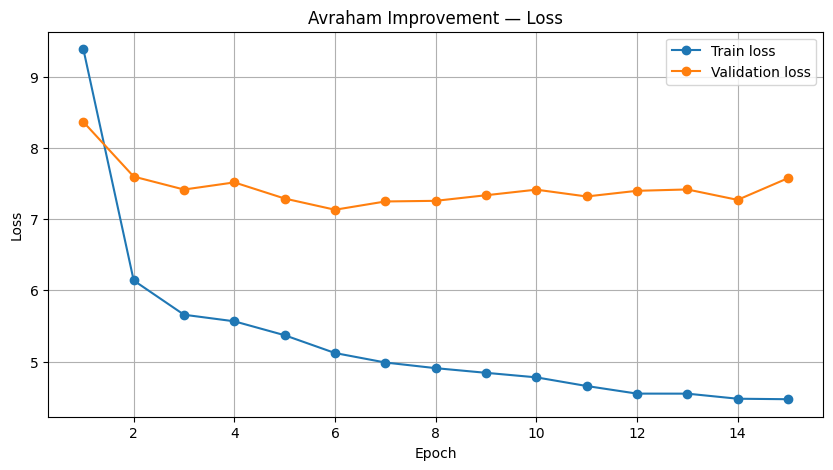

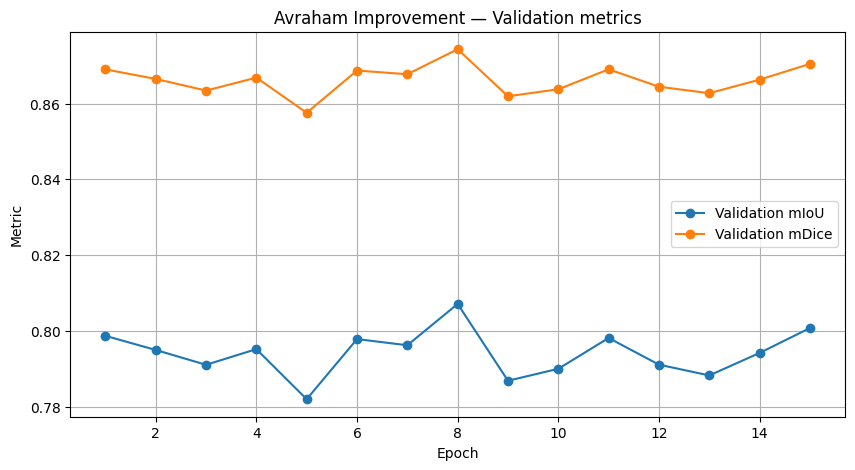

,epoch,train_loss,val_loss,val_mIoU,val_mDice,val_precision,val_recall,seconds,backbone_lr,main_lr
7,8,4.907167,7.257498,0.807119,0.874328,0.909517,0.879797,268.457493,0.000006,0.000029


In [18]:
# Cell 16 — Training curves

history_df = pd.read_csv(HISTORY_CSV)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Avraham Improvement — Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["val_mIoU"], marker="o", label="Validation mIoU")
plt.plot(history_df["epoch"], history_df["val_mDice"], marker="o", label="Validation mDice")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Avraham Improvement — Validation metrics")
plt.grid(True)
plt.legend()
plt.show()

display(history_df.loc[[history_df["val_mIoU"].idxmax()]])


In [19]:
# Cell 17 — Reload best checkpoint and inspect validation classes

best_processor = AutoImageProcessor.from_pretrained(OUTPUT_DIR)
best_model = (
    Mask2FormerForUniversalSegmentation
    .from_pretrained(OUTPUT_DIR)
    .to(DEVICE)
)

# Keep the current processor object for evaluation target sizing / post-processing.
processor = best_processor

best_val = evaluate_model(
    best_model,
    val_loader,
    threshold=VALIDATION_THRESHOLD,
)

print("Best validation mIoU:", best_val["mIoU"])
print("Best validation mDice:", best_val["mDice"])
print("Best validation precision:", best_val["mPrecision"])
print("Best validation recall:", best_val["mRecall"])

display(best_val["per_class"].sort_values("IoU"))


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Best validation mIoU: 0.8071189645309363
Best validation mDice: 0.8743276061615523
Best validation precision: 0.9095166317477947
Best validation recall: 0.8797972783317276


,class_id,class_name,IoU,Dice,Precision,Recall
18,18,object,0.000000,0.000000,NaN,0.000000
17,17,left_mirror,0.688257,0.815346,0.840960,0.791247
19,19,right_mirror,0.701458,0.824538,0.866867,0.786150
22,22,wheel,0.763243,0.865726,0.857042,0.874589
12,12,front_left_light,0.794662,0.885584,0.922050,0.851892
5,5,back_light,0.807146,0.893283,0.872204,0.915405
0,0,back_bumper,0.825419,0.904361,0.883916,0.925775
9,9,front_door,0.833361,0.909107,0.883950,0.935738
13,13,front_light,0.835749,0.910526,0.894553,0.927080
4,4,back_left_light,0.836993,0.911264,0.890995,0.932477


Selected image: m2f_improved_train/images/new_1_png_jpg.rf.058be8004f553297d10333df612e8ca1.jpg
Selected label: m2f_improved_train/labels/new_1_png_jpg.rf.058be8004f553297d10333df612e8ca1.txt
Repeated class: front_right_light
Count: 4


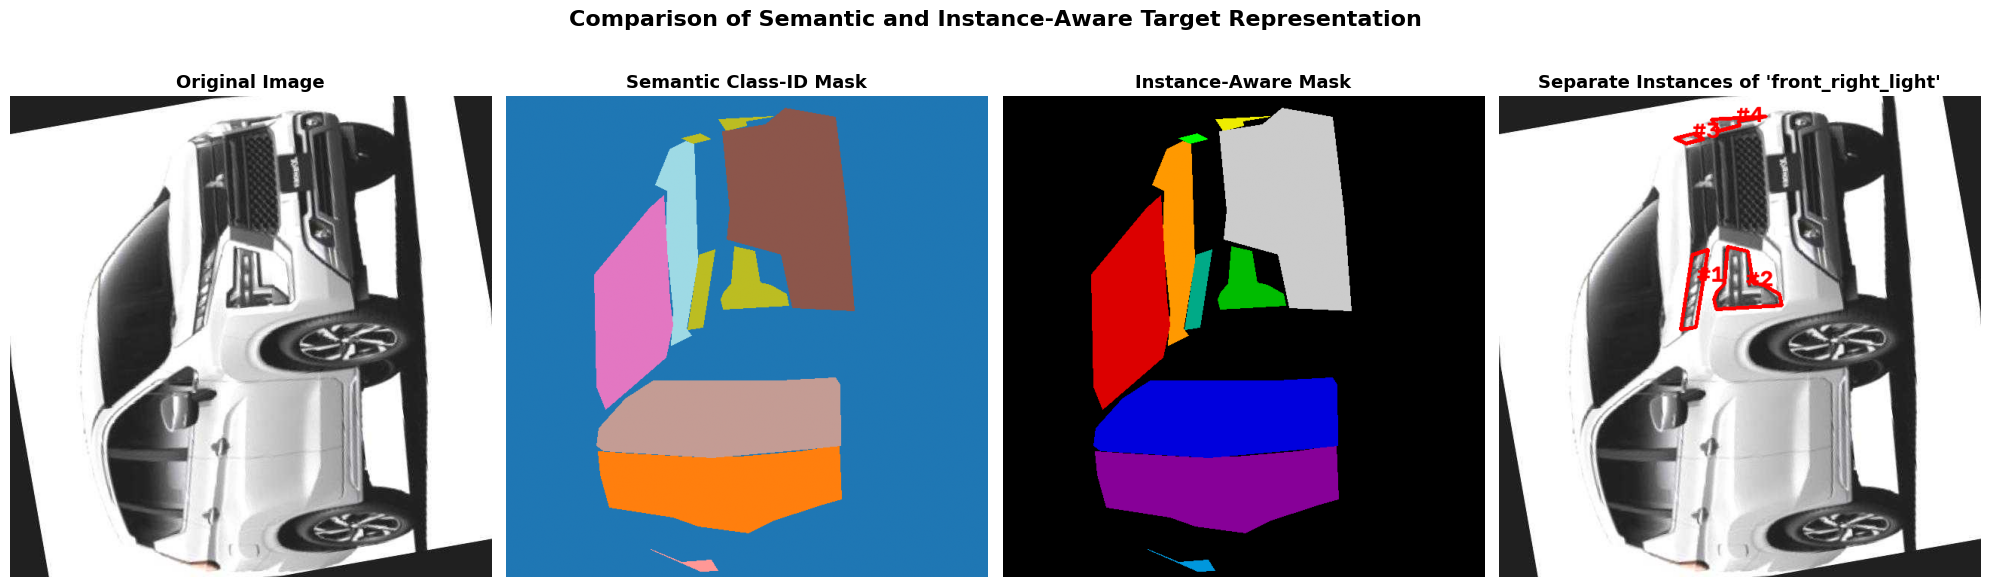

In [21]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter, defaultdict
import cv2

# =========================================================
# 1) SET YOUR PATHS
# =========================================================
from pathlib import Path

image_dir = Path("./m2f_improved_train/images")
label_dir = Path("./m2f_improved_train/labels")

# If your notebook already has class names defined, you can use them.
# Otherwise, put the class names here in the correct order.
class_names = [
    "back_bumper",
    "back_door",
    "back_glass",
    "back_left_door",
    "back_left_light",
    "back_right_door",
    "back_right_light",
    "front_bumper",
    "front_door",
    "front_glass",
    "front_left_door",
    "front_left_light",
    "front_right_door",
    "front_right_light",
    "hood",
    "left_mirror",
    "object",
    "right_mirror",
    "tailgate",
    "trunk",
    "wheel"
]

# If your notebook already has these variables, you can replace the above with:
# image_dir = train_images_dir
# label_dir = train_labels_dir
# class_names = CLASS_NAMES


# =========================================================
# 2) HELPERS
# =========================================================
def load_yolo_polygons(label_path):
    """
    Reads a YOLO segmentation txt file.
    Each line format:
    class_id x1 y1 x2 y2 x3 y3 ...
    coordinates are normalized to [0,1]
    """
    polygons = []
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        parts = line.split()
        class_id = int(float(parts[0]))
        coords = list(map(float, parts[1:]))

        if len(coords) < 6:
            continue  # need at least 3 points

        pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
        polygons.append({
            "class_id": class_id,
            "points_norm": pts
        })

    return polygons


def denormalize_polygon(points_norm, width, height):
    pts = points_norm.copy()
    pts[:, 0] = pts[:, 0] * width
    pts[:, 1] = pts[:, 1] * height
    return np.round(pts).astype(np.int32)


def polygon_center(pts):
    x = int(np.mean(pts[:, 0]))
    y = int(np.mean(pts[:, 1]))
    return x, y


def find_example_with_repeated_class(image_dir, label_dir, class_names):
    """
    Finds one example image where at least one class appears more than once.
    Prefer wheel if possible, otherwise choose the most repeated class.
    """
    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

    label_files = sorted(glob.glob(os.path.join(label_dir, "*.txt")))
    candidates = []

    for label_path in label_files:
        polygons = load_yolo_polygons(label_path)
        if not polygons:
            continue

        class_ids = [p["class_id"] for p in polygons]
        counts = Counter(class_ids)
        repeated = {cid: c for cid, c in counts.items() if c >= 2}

        if not repeated:
            continue

        base = os.path.splitext(os.path.basename(label_path))[0]

        image_path = None
        for ext in image_extensions:
            possible = os.path.join(image_dir, base + ext)
            if os.path.exists(possible):
                image_path = possible
                break

        if image_path is None:
            continue

        # Prefer wheel if available
        wheel_id = class_names.index("wheel") if "wheel" in class_names else None
        if wheel_id is not None and wheel_id in repeated:
            score = 1000 + repeated[wheel_id]
            selected_class_id = wheel_id
        else:
            selected_class_id = max(repeated, key=lambda k: repeated[k])
            score = repeated[selected_class_id]

        candidates.append((score, image_path, label_path, selected_class_id, repeated[selected_class_id]))

    if not candidates:
        return None

    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0]


# =========================================================
# 3) FIND A GOOD EXAMPLE
# =========================================================
result = find_example_with_repeated_class(image_dir, label_dir, class_names)

if result is None:
    raise ValueError("No image with repeated same-class objects was found.")

score, image_path, label_path, repeated_class_id, repeated_count = result

print("Selected image:", image_path)
print("Selected label:", label_path)
print("Repeated class:", class_names[repeated_class_id])
print("Count:", repeated_count)


# =========================================================
# 4) BUILD SEMANTIC MASK AND INSTANCE MASK
# =========================================================
image = np.array(Image.open(image_path).convert("RGB"))
h, w = image.shape[:2]

polygons = load_yolo_polygons(label_path)

# semantic mask: same class = same value
semantic_mask = np.zeros((h, w), dtype=np.int32)

# instance mask: every polygon gets unique instance ID
instance_mask = np.zeros((h, w), dtype=np.int32)

instance_to_class = {}
instance_centers = {}
instance_counter = 1

# Keep repeated-class instances for annotation
repeated_instances = []

for poly in polygons:
    class_id = poly["class_id"]
    pts = denormalize_polygon(poly["points_norm"], w, h)

    if len(pts) < 3:
        continue

    # Semantic mask: use class_id + 1 so 0 stays background
    cv2.fillPoly(semantic_mask, [pts], color=class_id + 1)

    # Instance-aware mask: each polygon gets a unique ID
    current_instance_id = instance_counter
    cv2.fillPoly(instance_mask, [pts], color=current_instance_id)

    instance_to_class[current_instance_id] = class_id
    instance_centers[current_instance_id] = polygon_center(pts)

    if class_id == repeated_class_id:
        repeated_instances.append(current_instance_id)

    instance_counter += 1

# =========================================================
# CLEAN OVERLAY FOR SAME-CLASS INSTANCES
# =========================================================
overlay = image.copy()

repeat_label = class_names[repeated_class_id]

local_instance_num = 1

for poly in polygons:
    class_id = poly["class_id"]

    if class_id != repeated_class_id:
        continue

    pts = denormalize_polygon(poly["points_norm"], w, h)

    if len(pts) < 3:
        continue

    # Draw polygon boundary
    cv2.polylines(
        overlay,
        [pts],
        isClosed=True,
        color=(255, 0, 0),
        thickness=3
    )

    # Find polygon center
    cx = int(np.mean(pts[:, 0]))
    cy = int(np.mean(pts[:, 1]))

    # Draw only the instance number
    cv2.putText(
        overlay,
        f"#{local_instance_num}",
        (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 0, 0),
        3,
        cv2.LINE_AA
    )

    local_instance_num += 1


# =========================================================
# PLOT
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(semantic_mask, cmap="tab20")
axes[1].set_title(
    "Semantic Class-ID Mask",
    fontsize=13,
    fontweight="bold"
)
axes[1].axis("off")

axes[2].imshow(instance_mask, cmap="nipy_spectral")
axes[2].set_title(
    "Instance-Aware Mask",
    fontsize=13,
    fontweight="bold"
)
axes[2].axis("off")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Separate Instances of '{repeat_label}'",
    fontsize=13,
    fontweight="bold"
)
axes[3].axis("off")

plt.suptitle(
    "Comparison of Semantic and Instance-Aware Target Representation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

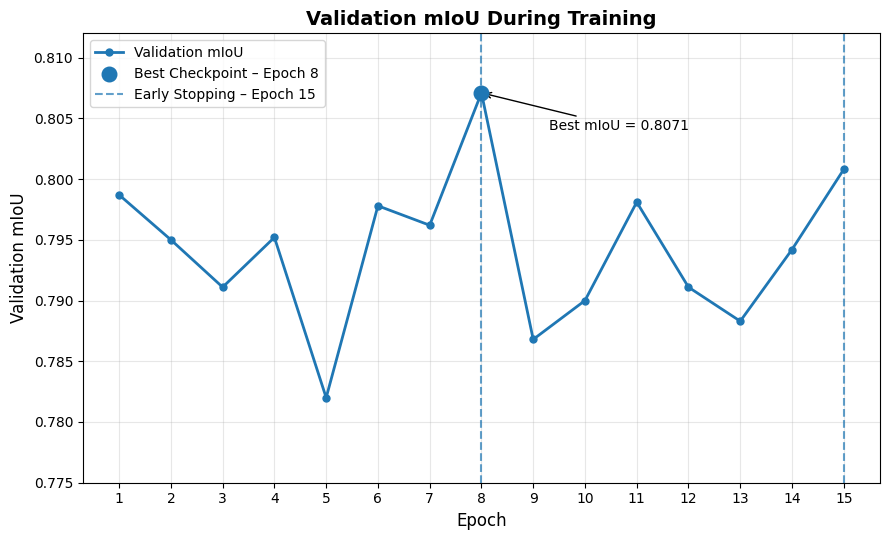

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Validation mIoU values taken directly from Ofek's saved notebook output
val_miou = [
    0.7987,
    0.7950,
    0.7911,
    0.7952,
    0.7820,
    0.7978,
    0.7962,
    0.8071,
    0.7868,
    0.7900,
    0.7981,
    0.7911,
    0.7883,
    0.7942,
    0.8008
]

epochs = np.arange(1, len(val_miou) + 1)

best_epoch = 8
early_stop_epoch = 15
best_value = val_miou[best_epoch - 1]

plt.figure(figsize=(9, 5.5))

plt.plot(
    epochs,
    val_miou,
    marker="o",
    markersize=5,
    linewidth=2,
    label="Validation mIoU"
)

# Best checkpoint
plt.scatter(
    best_epoch,
    best_value,
    s=110,
    zorder=5,
    label=f"Best Checkpoint – Epoch {best_epoch}"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    alpha=0.7
)

# Early stopping
plt.axvline(
    x=early_stop_epoch,
    linestyle="--",
    alpha=0.7,
    label=f"Early Stopping – Epoch {early_stop_epoch}"
)

plt.annotate(
    f"Best mIoU = {best_value:.4f}",
    xy=(best_epoch, best_value),
    xytext=(9.3, 0.804),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title(
    "Validation mIoU During Training",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation mIoU", fontsize=12)

plt.xticks(range(1, 16))
plt.ylim(0.775, 0.812)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## What to do after this notebook

Do **not** add test-set tuning cells here.

1. Take the directory saved in `OUTPUT_DIR`.
2. Run your external `evaluate_mask2former.py` on the exact same fixed test set used for NOA and AVRAHAM.
3. Save the evaluator output into a new results folder.
4. Add that folder to `compare_mask2former_models.py`.
5. Compare:
   - COCO AP50:95 / AP50 / AP75
   - instance Precision / Recall / F1
   - pixel mIoU / mDice
   - small / medium / large AP
   - per-class results

The key hypotheses to test are:

- **Wheel instance AP should improve** because repeated wheels are no longer merged into one training target.
- **Small-object AP should improve** due to higher input resolution and train-only sampling emphasis.
- **Mirror / light recall should improve** without sacrificing the strong large-part segmentation.
- **Back bumper should no longer be artificially down-weighted** by the old custom classification vector.
